# Tahap 13 — Pembagian Tingkat Rekaman versus Tingkat Subjek (C1)

Seluruh penelitian ini memakai pemisahan **tingkat subjek**. Notebook ini menjalankan sekali lagi
dengan pemisahan **tingkat rekaman**, yaitu praktik yang masih lazim pada literatur, lalu melaporkan
selisihnya.

## Mengapa ini dijalankan

Literatur 2025–2026 pada domain ini sedang mempersoalkan kebocoran data: hasil yang dilaporkan
menggelembung ketika rekaman dari subjek yang sama muncul di sisi latih dan sisi uji sekaligus,
sebab model dapat mengenali orangnya alih-alih penyakitnya.

Menyatakan "kami memakai pemisahan tingkat subjek" saja tidak memberi tahu pembaca **seberapa besar**
bedanya pada data ini. Menjalankan keduanya memberi angka itu, dan angka itu merupakan hasil
tersendiri, bukan sekadar kehati-hatian.

Skenario S4 sudah memperlihatkan bahwa arah bias kebocoran dapat **membalik** pada transfer lintas
tugas, dan bahwa arahnya bergantung kapasitas model. Notebook ini melengkapi gambarannya pada kasus
yang paling lazim dilaporkan: klasifikasi di dalam distribusi yang sama.

## Yang dibandingkan

| Pembagian | Yang ditahan | Yang diukur |
|---|---|---|
| Tingkat subjek | seluruh rekaman satu subjek | Generalisasi ke orang baru |
| Tingkat rekaman | satu rekaman saja | Generalisasi ke rekaman baru dari orang yang mungkin sudah dikenal |

Selisihnya adalah **besar penggelembungan akibat kebocoran subjek**, diukur pada protokol yang
identik dalam segala hal lain: patch, epoch, seed, jumlah fold, dan arsitektur.

In [1]:
import sys, time, pickle
sys.path.insert(0, "../src")
from pathlib import Path
import numpy as np, pandas as pd, torch
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedGroupKFold, StratifiedKFold
from sklearn.metrics import roc_auc_score

from preprocessing import muat_cache, Normalisasi
from model import PDClassifier
from training import latih, prediksi
from viz import WARNA, TINTA, pasang_gaya, rapikan
from artefak import muat_artefak, simpan_atomik

pasang_gaya()
DEV = "cuda" if torch.cuda.is_available() else "cpu"

P = 7                    # dibekukan S2
EPOCHS = 35              # dibekukan S2
SEED = 0
ARSITEKTUR = ["mamba2", "gru", "mamba3"]

HASIL = Path("../results"); HASIL.mkdir(exist_ok=True)
ARTEFAK = HASIL / "c1_artefak.pkl"

rek = muat_cache(Path("../data/cache/uci395_fs100.npz"))
y = np.array([r.label for r in rek])
grup = np.array([r.subjek for r in rek])

beku = pd.read_csv(HASIL / "s2_parameter_dibekukan.csv")
assert P == int(beku.patch_halus[0]) and EPOCHS == int(beku.epoch_dibekukan[0])
print(f"perangkat: {DEV} | patch {P} | epoch {EPOCHS} | seed {SEED}")
print(f"{len(rek)} rekaman dari {len(set(grup))} subjek "
      f"({len(rek)/len(set(grup)):.2f} rekaman per subjek)")

/home/agribychaniago/Python Projects/Skripsi/.venv/lib/python3.11/site-packages/mamba_ssm/ops/selective_scan_interface.py:163: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd
/home/agribychaniago/Python Projects/Skripsi/.venv/lib/python3.11/site-packages/mamba_ssm/ops/selective_scan_interface.py:239: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  @custom_bwd
/home/agribychaniago/Python Projects/Skripsi/.venv/lib/python3.11/site-packages/mamba_ssm/ops/triton/layer_norm.py:985: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  @custom_fwd
/home/agribychaniago/Python Projects/Skripsi/.venv/lib/python3.11/site-packages/mamba_ssm/ops/triton/layer_norm.py:1044: FutureWarning: `torch.cuda.amp.custom_bwd(args

perangkat: cuda | patch 7 | epoch 35 | seed 0
207 rekaman dari 77 subjek (2.69 rekaman per subjek)


## 1. Dua pembagian, protokol identik

Satu-satunya perbedaan adalah pengelompokan. Jumlah fold, stratifikasi label, seed pengacakan,
arsitektur, patch, dan epoch seluruhnya sama, sehingga selisih yang terukur hanya dapat berasal dari
pengelompokannya.

Metrik dilaporkan pada **dua tingkat**:

- **Tingkat rekaman** — AUC atas seluruh rekaman. Inilah bentuk yang lazim dilaporkan pada
  penelitian yang memakai pembagian tingkat rekaman, sehingga inilah yang sebanding dengan angka
  mereka.
- **Tingkat subjek** — probabilitas dirata-ratakan per subjek lebih dahulu. Inilah yang dipakai
  seluruh skenario lain penelitian ini.

Keduanya dilaporkan agar penggelembungan dapat dibaca pada satuan yang sama dengan yang dipakai
literatur pembandingnya.

In [2]:
def auc_rekaman(logit):
    return float(roc_auc_score(y, 1 / (1 + np.exp(-logit))))


def auc_subjek(logit):
    prob = 1 / (1 + np.exp(-logit))
    agg = pd.DataFrame({"s": grup, "p": prob, "l": y}).groupby("s").agg(
        p=("p", "mean"), l=("l", "first"))
    return float(roc_auc_score(agg.l, agg.p))


def jalankan(arsitektur, tingkat):
    """Latih dan uji dengan pembagian tingkat subjek atau tingkat rekaman."""
    if tingkat == "subjek":
        pembagi = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
        lipatan = pembagi.split(np.zeros(len(rek)), y, grup)
    else:
        pembagi = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        lipatan = pembagi.split(np.zeros(len(rek)), y)

    logit_oof = np.zeros(len(rek))
    bocor = 0
    for i_latih, i_uji in lipatan:
        bocor += len(set(grup[i_latih]) & set(grup[i_uji]))
        norm = Normalisasi().fit([rek[i] for i in i_latih])
        torch.manual_seed(SEED)
        m = PDClassifier(encoder=arsitektur, patch_size=P).to(DEV)
        latih(m, rek, list(i_latih), norm, epochs=EPOCHS, device=DEV, seed=SEED)
        logit, _ = prediksi(m, rek, list(i_uji), norm, device=DEV)
        logit_oof[i_uji] = logit
    return {"arsitektur": arsitektur, "tingkat": tingkat,
            "auc_rekaman": auc_rekaman(logit_oof), "auc_subjek": auc_subjek(logit_oof),
            "subjek_bocor_per_fold": bocor / 5}

## 2. Menjalankan

Jumlah subjek yang muncul di kedua sisi dihitung dan dilaporkan, bukan diandaikan. Pada pembagian
tingkat subjek angkanya harus **nol**; bila tidak, ada kekeliruan implementasi dan hasil apa pun di
atasnya tidak sahih.

In [3]:
art = muat_artefak(ARTEFAK) or []
ada = {(a["arsitektur"], a["tingkat"]) for a in art}
perlu = [(a, t) for a in ARSITEKTUR for t in ["subjek", "rekaman"] if (a, t) not in ada]
print(f"{ARTEFAK.name}: memakai ulang {len(ada)} kombinasi")
print(f"{ARTEFAK.name}: menghitung {perlu if perlu else 'tidak ada'}")

if perlu:
    t0 = time.time()
    for arsitektur, tingkat in perlu:
        t1 = time.time()
        h = jalankan(arsitektur, tingkat)
        art.append(h)
        print(f"  {arsitektur:7s} {tingkat:8s} {time.time()-t1:6.1f}s  "
              f"AUC rekaman={h['auc_rekaman']:.4f} subjek={h['auc_subjek']:.4f}  "
              f"subjek bocor/fold={h['subjek_bocor_per_fold']:.1f}")
    simpan_atomik(ARTEFAK, art)
    print(f"total {time.time()-t0:.1f}s, disimpan ke {ARTEFAK.name}")

df = pd.DataFrame(art)
display(df.round(4))

cek = df[df.tingkat == "subjek"].subjek_bocor_per_fold.max()
print()
print(f"Subjek yang muncul di kedua sisi pada pembagian tingkat subjek: {cek:.1f} per fold")
print("BENAR — tidak ada kebocoran" if cek == 0 else "SALAH — implementasi pembagian bermasalah")

c1_artefak.pkl: memakai ulang 0 kombinasi
c1_artefak.pkl: menghitung [('mamba2', 'subjek'), ('mamba2', 'rekaman'), ('gru', 'subjek'), ('gru', 'rekaman'), ('mamba3', 'subjek'), ('mamba3', 'rekaman')]


  mamba2  subjek    111.3s  AUC rekaman=0.8962 subjek=0.9344  subjek bocor/fold=0.0


  mamba2  rekaman    99.0s  AUC rekaman=0.9312 subjek=0.9710  subjek bocor/fold=35.0


  gru     subjek    186.2s  AUC rekaman=0.9003 subjek=0.9548  subjek bocor/fold=0.0


  gru     rekaman   185.8s  AUC rekaman=0.9048 subjek=0.9462  subjek bocor/fold=35.0


  mamba3  subjek    114.0s  AUC rekaman=0.8728 subjek=0.9366  subjek bocor/fold=0.0


  mamba3  rekaman    86.9s  AUC rekaman=0.8817 subjek=0.9366  subjek bocor/fold=35.0
total 783.2s, disimpan ke c1_artefak.pkl


,arsitektur,tingkat,auc_rekaman,auc_subjek,subjek_bocor_per_fold
0,mamba2,subjek,0.8962,0.9344,0.0
1,mamba2,rekaman,0.9312,0.9710,35.0
2,gru,subjek,0.9003,0.9548,0.0
3,gru,rekaman,0.9048,0.9462,35.0
4,mamba3,subjek,0.8728,0.9366,0.0
5,mamba3,rekaman,0.8817,0.9366,35.0



Subjek yang muncul di kedua sisi pada pembagian tingkat subjek: 0.0 per fold
BENAR — tidak ada kebocoran


## 3. Besar penggelembungan

In [4]:
piv = df.pivot(index="arsitektur", columns="tingkat",
               values=["auc_rekaman", "auc_subjek"]).reindex(ARSITEKTUR)
gel = pd.DataFrame({
    "auc_rekaman_subjekfold": piv[("auc_rekaman", "subjek")],
    "auc_rekaman_rekamanfold": piv[("auc_rekaman", "rekaman")],
    "penggelembungan": piv[("auc_rekaman", "rekaman")] - piv[("auc_rekaman", "subjek")],
})
display(gel.round(4))

print("=" * 74)
print("PENGGELEMBUNGAN AKIBAT PEMBAGIAN TINGKAT REKAMAN")
print("=" * 74)
for a, b in gel.iterrows():
    print(f"  {a:8s} {b.auc_rekaman_subjekfold:.4f} -> {b.auc_rekaman_rekamanfold:.4f}  "
          f"({b.penggelembungan:+.4f})")
print()
print(f"  Rata-rata: {gel.penggelembungan.mean():+.4f}")
print()
print("  Positif berarti pembagian tingkat rekaman melebih-lebihkan performa.")
print("  Angka ini menyatakan berapa banyak AUC yang berasal dari mengenali ORANG,")
print("  bukan dari mengenali penyakitnya.")

,auc_rekaman_subjekfold,auc_rekaman_rekamanfold,penggelembungan
arsitektur,,,
mamba2,0.8962,0.9312,0.0350
gru,0.9003,0.9048,0.0045
mamba3,0.8728,0.8817,0.0089


PENGGELEMBUNGAN AKIBAT PEMBAGIAN TINGKAT REKAMAN
  mamba2   0.8962 -> 0.9312  (+0.0350)
  gru      0.9003 -> 0.9048  (+0.0045)
  mamba3   0.8728 -> 0.8817  (+0.0089)

  Rata-rata: +0.0161

  Positif berarti pembagian tingkat rekaman melebih-lebihkan performa.
  Angka ini menyatakan berapa banyak AUC yang berasal dari mengenali ORANG,
  bukan dari mengenali penyakitnya.


### Gambar 1 — Dua pembagian berdampingan

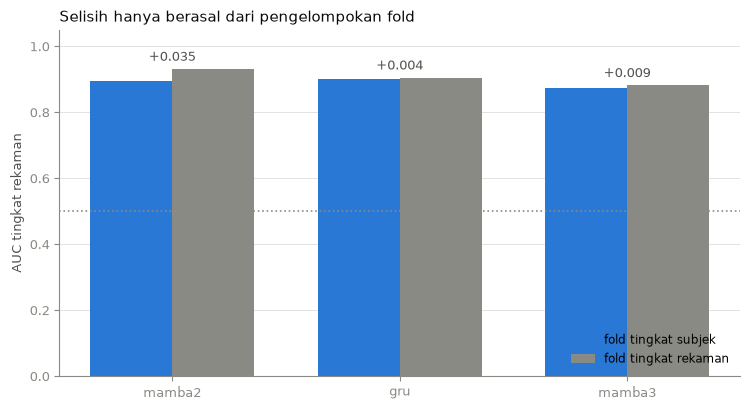

In [5]:
fig, ax = plt.subplots(figsize=(7.6, 4.2))
rapikan(ax)
pos = np.arange(len(ARSITEKTUR)); lebar = 0.36
ax.bar(pos - lebar/2, gel.auc_rekaman_subjekfold, width=lebar,
       color=WARNA["biru"], label="fold tingkat subjek")
ax.bar(pos + lebar/2, gel.auc_rekaman_rekamanfold, width=lebar,
       color=WARNA["netral"], label="fold tingkat rekaman")
for i, (a, b) in enumerate(gel.iterrows()):
    ax.annotate(f"{b.penggelembungan:+.3f}",
                xy=(i, max(b.auc_rekaman_subjekfold, b.auc_rekaman_rekamanfold)),
                xytext=(0, 6), textcoords="offset points",
                ha="center", fontsize=9, color=TINTA["sekunder"])
ax.axhline(0.5, color=WARNA["netral"], ls=":", lw=1.2)
ax.set_xticks(pos); ax.set_xticklabels(ARSITEKTUR)
ax.set_ylim(0, 1.05); ax.set_ylabel("AUC tingkat rekaman")
ax.set_title("Selisih hanya berasal dari pengelompokan fold", loc="left")
ax.legend(fontsize=8.5, loc="lower right")
plt.tight_layout(); plt.show()

In [6]:
df.to_csv(HASIL / "c1_perbandingan.csv", index=False)
gel.reset_index().to_csv(HASIL / "c1_penggelembungan.csv", index=False)
print(f"disimpan ke {HASIL.name}/c1_perbandingan.csv dan c1_penggelembungan.csv")

disimpan ke results/c1_perbandingan.csv dan c1_penggelembungan.csv


## 4. Ringkasan

**Yang diukur.** Berapa besar AUC yang hilang ketika rekaman dari subjek yang sama tidak lagi boleh
berada di kedua sisi pembagian. Selisih itu bukan galat, melainkan bagian performa yang berasal dari
pengenalan subjek.

**Cara membacanya bersama Skenario S4.** Di dalam distribusi yang sama, kebocoran subjek
**menggelembungkan** performa — itulah yang diukur di sini. Pada transfer lintas tugas, kebocoran
yang sama justru **membalikkannya**, dan arah pembalikannya bergantung pada kapasitas model (Subbab
3.6.3). Kedua pengukuran itu diperlukan; salah satunya saja memberi gambaran yang keliru.

**Batasan.** Satu seed, sesuai kedalaman eksploratori Subbab 3.6.3. Perbandingannya juga terbatas
pada lima fold dengan pembagi yang sama, sehingga tidak menyatakan apa pun mengenai skema pembagian
lain seperti leave-one-subject-out.